In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# FaIR analysis of California offsetting

We're interested in understanding how the cooling affect implied by the CO2e metric compares to the actual portfolio of multi-gas emission reductions. We use FaIR to compare temperature outcomes of: 

1. gas-specific offset project emissions reductions versus the "equivalent" CO2 reductions implied by the CO2e metric
2. the offsetting program as a whole (both project fluxes and offset-justified emissions)

inputs:
- ca_project_fluxes.csv
- ca_justified_emissions_fluxes.csv

scenarios:
- baseline: ssp2-4.5 only
- projects_only: ssp245 + credited project fluxes (supply side; physical emissions justified by using offsets)
- emissions_only: ssp245 + offset-justified emissions (demand side; physical project co2, ch4, and ODS fluxes)
- net_program: ssp245 + offset-justified emissions + project fluxes
- claimed_project: baseline + project co2 fluxes + ch4 and ODS project fluxes converted to co2e
- actual_ch4: baseline + physical ch4 project fluxes only
- claimed_ch4: baseline + ch4 project fluxes converted to co2e only
- actual_ods: baseline + physical ODS project fluxes only
- claimed_ods: baseline + ODS project fluxes converted to co2e only

The justified emissions file inlcuded CH4, CO2 and N2O emissions. The project flux file includes CO2, CH4, CFC-11, CFC-12, CFC-113, CFC-114, and CFC-115 separately. FaIR does not include a default CFC-13 configuration, so CFC-13 project fluxes and their associated share of justified emissions are excluded from the gas-specific temperature analysis.

In [28]:
# ----------------------------
# Inputs
# ----------------------------

PROJECTS_FILE = "../timeseries-data/output-data/ca_project_fluxes.csv"
EMISSIONS_FILE = "../timeseries-data/output-data/ca_justified_emissions_fluxes.csv"
FAIR_PARAMS_FILE = "../timeseries-data/input-data/fair/calibrated_constrained_parameters_calibration1.4.1.csv"
FAIR_SPECIES_CONFIG_FILE = "../timeseries-data/input-data/fair/species_configs_properties_calibration1.4.1.csv"
BASELINE_SCENARIO = "ssp245"

ODS_COLUMN_TO_SPECIES = {"cfc-11_flux": "CFC-11", "cfc-12_flux": "CFC-12", "cfc-113_flux": "CFC-113", "cfc-114_flux": "CFC-114", "cfc-115_flux": "CFC-115"}
ODS_SPECIES = list(ODS_COLUMN_TO_SPECIES.values())
ODS_COLUMNS = list(ODS_COLUMN_TO_SPECIES.keys())

ODS_GWP20 = {"CFC-11": 6900, "CFC-12": 6900, "CFC-13": 10900, "CFC-113": 6490, "CFC-114": 7710, "CFC-115": 5860}
ODS_GWP100 = {"CFC-11": 4660, "CFC-12": 10200, "CFC-13": 13900, "CFC-113": 5820, "CFC-114": 8590, "CFC-115": 7670}
ODS_GWP500 = {"CFC-11": 1620, "CFC-12": 5200, "CFC-13": 16400, "CFC-113": 2700, "CFC-114": 8730, "CFC-115": 9990}
ODS_GTP20 = {"CFC-11": 6890, "CFC-12": 11300, "CFC-13": 11700, "CFC-113": 6730, "CFC-114": 8190, "CFC-115": 6310}
ODS_GTP50 = {"CFC-11": 4890, "CFC-12": 11000, "CFC-13": 14200, "CFC-113": 6250, "CFC-114": 9020, "CFC-115": 7810}
ODS_GTP100 = {"CFC-11": 2340, "CFC-12": 8450, "CFC-13": 15900, "CFC-113": 4470, "CFC-114": 8550, "CFC-115": 8980}

# year-dependent gwp100 for ch4
def gwp_ch4(year):
    return 21 if year <= 2020 else 25

# gwp100 for cfc-12
gwp_cfc12 = ODS_GWP100["CFC-12"]

In [29]:
# ----------------------------
# load data
# ----------------------------

df_p = pd.read_csv(PROJECTS_FILE)
df_p.columns = df_p.columns.str.lower()
df_p = df_p[["year", "co2_flux", "ch4_flux", "cfc-11_flux", "cfc-12_flux", "cfc-13_flux", "cfc-113_flux", "cfc-114_flux", "cfc-115_flux", "total_credits_used"]].sort_values("year").fillna(0)

df_e = pd.read_csv(EMISSIONS_FILE)
df_e.columns = df_e.columns.str.lower()
df_e = df_e[["year", "co2_justified", "ch4_justified", "n2o_justified"]].sort_values("year").fillna(0)

# remove the share of justified emissions associated with cfc-13 credits, which aren't built into FaIR
cfc13_adjustment = df_p[["year", "cfc-13_flux", "total_credits_used"]].copy()
cfc13_adjustment["cfc13_credits"] = -cfc13_adjustment["cfc-13_flux"].clip(upper=0) * ODS_GWP100["CFC-13"]
cfc13_adjustment["retained_credit_fraction"] = np.where(cfc13_adjustment["total_credits_used"] > 0, 1 - cfc13_adjustment["cfc13_credits"] / cfc13_adjustment["total_credits_used"], 1)
if ((cfc13_adjustment["retained_credit_fraction"] < 0) | (cfc13_adjustment["retained_credit_fraction"] > 1)).any():
    raise ValueError("CFC-13 credit adjustment produced a retained fraction outside [0, 1].")

df_e = df_e.merge(cfc13_adjustment[["year", "retained_credit_fraction"]], on="year", how="left")
df_e["retained_credit_fraction"] = df_e["retained_credit_fraction"].fillna(1)
df_e[["co2_justified", "ch4_justified", "n2o_justified"]] = df_e[["co2_justified", "ch4_justified", "n2o_justified"]].mul(df_e["retained_credit_fraction"], axis=0)
df_e = df_e.drop(columns="retained_credit_fraction")

print("CFC-13-attributable justified emissions removed (tCO2e):", cfc13_adjustment["cfc13_credits"].sum())

CFC-13-attributable justified emissions removed (tCO2e): 10142.315832778115


# Run FaIR simulations

In [30]:
# ----------------------------
# Set up FaIR
# ----------------------------

import contextlib
import os

f = FAIR()
f.define_time(1750, 2200, 1)
f.define_scenarios([BASELINE_SCENARIO, "emissions_only", "projects_only", "net_program", "claimed_project", "actual_ch4", "claimed_ch4", "actual_ods", "claimed_ods"])
f.define_configs(["central"])

all_species, all_props = read_properties()

species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES, "CO2"]
properties = {s: all_props[s] for s in species}

properties["CO2 FFI"]["input_mode"] = "emissions"
properties["CO2 FFI"]["greenhouse_gas"] = False

properties["CO2 AFOLU"]["input_mode"] = "emissions"
properties["CO2 AFOLU"]["greenhouse_gas"] = False

properties["CH4"]["input_mode"] = "emissions"
properties["CH4"]["greenhouse_gas"] = True

properties["N2O"]["input_mode"] = "emissions"
properties["N2O"]["greenhouse_gas"] = True

for sp in ODS_SPECIES:
    properties[sp]["input_mode"] = "emissions"
    properties[sp]["greenhouse_gas"] = True

properties["CO2"]["input_mode"] = "calculated"
properties["CO2"]["greenhouse_gas"] = True

f.define_species(species, properties)
f.allocate()
f.fill_species_configs()

# use the central three-layer energy-balance configuration from the FaIR basic example
fill(f.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
fill(f.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
fill(f.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

In [31]:
# ----------------------------
# load baseline emissions
# ----------------------------

backup = list(f.scenarios)
f.scenarios = [BASELINE_SCENARIO]
f.fill_from_rcmip()
f.scenarios = backup

for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES]:
    base = f.emissions.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values

    for scen in ["emissions_only", "projects_only", "net_program", "claimed_project", "actual_ch4", "claimed_ch4", "actual_ods", "claimed_ods"]:
        fill(f.emissions, base, scenario=scen, config="central", specie=sp)

In [32]:
# ----------------------------
# apply project perturbations
# ----------------------------

timepoints = np.asarray(f.timepoints, dtype=float)

for _, row in df_p.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    # convert units
    co2_p = row["co2_flux"] / 1e9  # Conversion from ton to gigaton
    ch4_p = row["ch4_flux"] / 1e6  # Conversion from ton to megaton
    ods_p = {sp: row[column] / 1e3 for column, sp in ODS_COLUMN_TO_SPECIES.items()}  # Conversion from ton to kiloton
    ods_co2e = sum(row[column] * ODS_GWP100[sp] for column, sp in ODS_COLUMN_TO_SPECIES.items())

    # projects_only + net program: all project fluxes enter as physical gases
    for scen in ["projects_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_p
        for sp in ODS_SPECIES:
            f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie=sp)].values += ods_p[sp]

    # claimed_project: co2 project fluxes + ch4 and ods project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_project", config="central", specie="CO2 FFI")].values += (row["co2_flux"] + row["ch4_flux"] * gwp_ch4(year) + ods_co2e) / 1e9

    # actual_ch4: only physical ch4 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_ch4", config="central", specie="CH4")].values += ch4_p

    # claimed_ch4: only ch4 project flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ch4", config="central", specie="CO2 FFI")].values += row["ch4_flux"] * gwp_ch4(year) / 1e9

    # actual_ods: only physical ods project fluxes
    for sp in ODS_SPECIES:
        f.emissions.loc[dict(timepoints=yr, scenario="actual_ods", config="central", specie=sp)].values += ods_p[sp]

    # claimed_ods: only ods project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ods", config="central", specie="CO2 FFI")].values += ods_co2e / 1e9

In [33]:
# ----------------------------
# apply offset-justified emissions
# ----------------------------

for _, row in df_e.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    co2_e = row["co2_justified"] / 1e9
    ch4_e = row["ch4_justified"] / 1e6
    n2o_e = row["n2o_justified"] / 1e6

    # emissions_only + net program: all justified emissions fluxes enter as physical gases
    for scen in ["emissions_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="N2O")].values += n2o_e

In [34]:
# ----------------------------
# initialise + run
# ----------------------------

initialise(f.concentration, 278.0, specie="CO2")
initialise(f.concentration, 730.0, specie="CH4")
initialise(f.concentration, 270.0, specie="N2O")
for sp in ODS_SPECIES:
    initialise(f.concentration, 0.0, specie=sp)

initialise(f.forcing, 0.0)
initialise(f.temperature, 0.0)
initialise(f.cumulative_emissions, 0.0)
initialise(f.airborne_emissions, 0.0)
initialise(f.ocean_heat_content_change, 0.0)

f.run()

Running 9 projections in parallel: 100%|█| 450/450 [00:00<00:00, 5872.22timestep


In [45]:
# ----------------------------
# 841-member uncertainty ensemble
# net offset program only
# ----------------------------
import time

# load calibrated constrained parameter sets
df_configs = pd.read_csv(FAIR_PARAMS_FILE, index_col=0)
ensemble_configs = df_configs.index
print(f"Setting up {len(ensemble_configs)}-member FaIR ensemble...")

# standard calibrated constrained FaIR setup
f_ens = FAIR(ch4_method="Thornhill2021")
f_ens.define_time(1750, 2200, 1)
f_ens.define_scenarios([BASELINE_SCENARIO, "net_program"])
f_ens.define_configs(ensemble_configs)

# use the same species as the main analysis
species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES, "CO2"]
species_ens, properties_ens = read_properties(filename=FAIR_SPECIES_CONFIG_FILE, species=species)

f_ens.define_species(species_ens, properties_ens)
f_ens.allocate()

# load calibrated species defaults and 841-member parameter ensemble
f_ens.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
f_ens.override_defaults(FAIR_PARAMS_FILE)
fill(f_ens.climate_configs["stochastic_run"], False)
fill(f_ens.climate_configs["use_seed"], False)

# copy already-constructed emissions from the central run
emissions_species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES]

for scen in [BASELINE_SCENARIO, "net_program"]:
    for sp in emissions_species:
        source = f.emissions.loc[dict(scenario=scen, config="central", specie=sp)].values
        # broadcast the same emissions trajectory across all 841 configs
        f_ens.emissions.loc[dict(scenario=scen, specie=sp)].values[:] = source[:, None]

# initialise using config-specific calibrated baseline concentrations
initialise(f_ens.concentration, f_ens.species_configs["baseline_concentration"])
initialise(f_ens.forcing, 0.0)
initialise(f_ens.temperature, 0.0)
initialise(f_ens.cumulative_emissions, 0.0)
initialise(f_ens.airborne_emissions, 0.0)
initialise(f_ens.ocean_heat_content_change, 0.0)

# run all configs together
print(f"Running {len(ensemble_configs)} ensemble members " f"for baseline + net program...")

start = time.time()
f_ens.run(progress=True)
elapsed = time.time() - start
print(f"Ensemble complete in {elapsed:.1f} seconds.")

Setting up 841-member FaIR ensemble...
Running 841 ensemble members for baseline + net program...


Running 1682 projections in parallel: 100%|█| 450/450 [00:01<00:00, 436.49timest

Ensemble complete in 1.9 seconds.


# Exploring program temp impact

First, we explore how the cooling affect of the project fluxes and the warming affect of justified emissions combine into a program-wide temperature impact. We use the central FaIR configuration for the primary temperature trajectories to maintain consistency with the subsequent sensitivity analyses. 

To characterize climate-model uncertainty, we also run the net offset program across the standard 841-member calibrated and constrained FaIR ensemble. The central trajectory is shown as the point estimate, with shading representing ±1 standard deviation in the emsemble modeled temp response.

In [48]:
# ----------------------------
# extract temperature trajectories
# ----------------------------

years = np.asarray(f.timebounds, dtype=float)
baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
emissions_only = f.temperature.loc[dict(scenario="emissions_only", config="central", layer=0)]
projects_only = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
net_program = f.temperature.loc[dict(scenario="net_program", config="central", layer=0)]

# paired net-program temperature impact for every ensemble member
net_program_ensemble = (f_ens.temperature.loc[dict(scenario="net_program", layer=0)] - f_ens.temperature.loc[dict(scenario=BASELINE_SCENARIO, layer=0)])

# ensemble mean and standard deviation
net_program_central = (net_program - baseline).values
net_program_sd = net_program_ensemble.std(dim="config").values

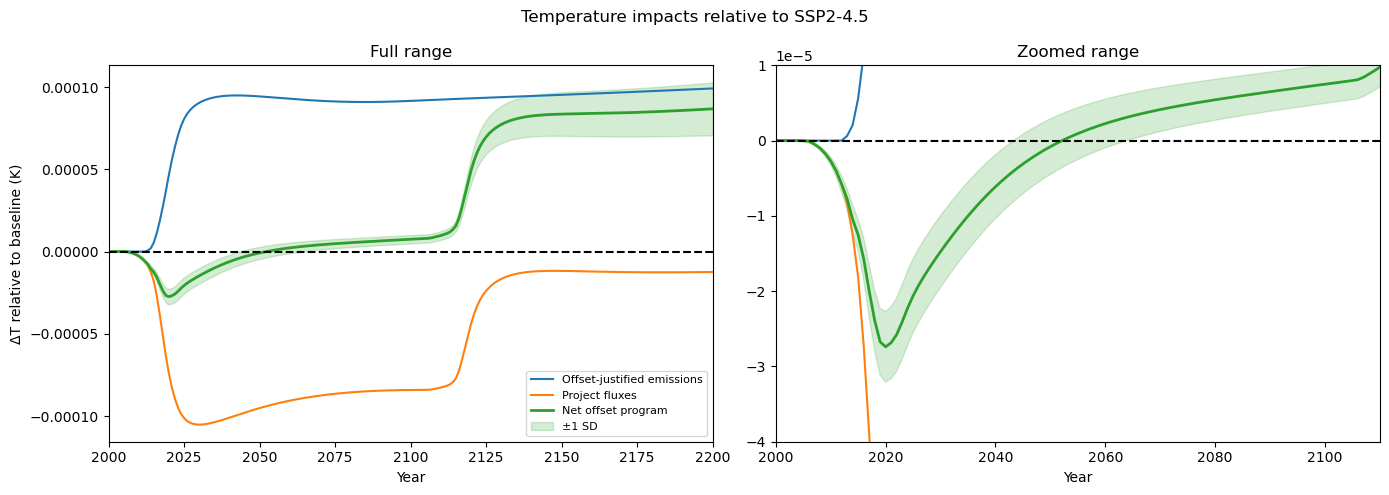

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full view
axes[0].plot(years, emissions_only - baseline, label="Offset-justified emissions")
axes[0].plot(years, projects_only - baseline, label="Project fluxes")
line, = axes[0].plot(years, net_program_central, label="Net offset program", linewidth=2)
axes[0].fill_between(years, net_program_central - net_program_sd, net_program_central + net_program_sd, color=line.get_color(), alpha=0.2, label="±1 SD")

axes[0].axhline(0, ls="--", color="k")
axes[0].set_xlim(2000, 2200)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("ΔT relative to baseline (K)")
axes[0].set_title("Full range")
axes[0].legend(fontsize=8)

# zoomed view
axes[1].plot(years, emissions_only - baseline, label="Offset-justified emissions")
axes[1].plot(years, projects_only - baseline, label="Project fluxes")
line, = axes[1].plot(years, net_program_central, label="Net offset program", linewidth=2)
axes[1].fill_between(years, net_program_central - net_program_sd, net_program_central + net_program_sd, color=line.get_color(), alpha=0.2)

axes[1].axhline(0, ls="--", color="k")
axes[1].set_xlim(2000, 2110)
axes[1].set_ylim(-0.00004, 0.00001)
axes[1].set_xlabel("Year")
axes[1].set_title("Zoomed range")

fig.suptitle("Temperature impacts relative to SSP2-4.5")
plt.tight_layout()
plt.show()

##### We can also determine in which years in which the program as a whole begins provide more or less of a cooling effect than implied by the co2e equivalent offsetting logic — i.e. "crossover years". 

In [51]:
# ----------------------------
# calculate crossover year and uncertainty
# ----------------------------

def find_crossover(years, diff, min_year=2025):
    # ignore irrelevant early crossings
    mask = years >= min_year
    y = years[mask]
    d = np.asarray(diff)[mask]
    crossing_indices = np.where(np.diff(np.sign(d)) != 0)[0]
    if len(crossing_indices) == 0:
        return np.nan

    # use first crossover after min_year
    i = crossing_indices[0]
    return y[i] - d[i] * (y[i + 1] - y[i]) / (d[i + 1] - d[i])

# central run
central_crossover = find_crossover(years,net_program - baseline)

# ensemble members
ensemble_crossovers = []
for config in net_program_ensemble.config.values:
    diff = net_program_ensemble.sel(config=config).values
    ensemble_crossovers.append(find_crossover(years, diff))

ensemble_crossovers = np.asarray(ensemble_crossovers)
ensemble_crossovers = ensemble_crossovers[~np.isnan(ensemble_crossovers)]
crossover_sd = np.std(ensemble_crossovers)

print(
    f"Crossover year: {central_crossover:.1f} "
    f"± {crossover_sd:.1f} years (1 SD)")

Crossover year: 2052.1 ± 11.0 years (1 SD)


The program as a whole eventually becomes net warming in 2052. In the subsequent sections, we explore how the following factors influence the crossover year:

1. The influence of each gas and it's GWP100 conversion influences the total program trajectory.
2. The choice of equivalency metric (what would have been different if gwp20, gtp50, gtp100, or like-for-like logic had been applied instead of gwp100?)
3. How coninued generation of CH4, ODS and CO2 credits would impact the eventual temperature crossover year.
4. How additionality issues in each type of credit impact the temperature trajectory and crossover year.

## 1. Impact of the gwp100 conversion

First, we compare the cooling affect of the actual portfolio of offset project fluxes versus the claimed cooling effect of an "equivalent" CO2 flux. We are not looking at net program trajectories to avoid assumptions about which credits went to CO2 vs N2O vs CH4 justified emissions. This exercise assumes project fluxes and CO2e justified emissions occur in the same year.

In [39]:
# extract temperature trajectories
years = np.asarray(f.timebounds, dtype=float)

baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
actual = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
claimed = f.temperature.loc[dict(scenario="claimed_project", config="central", layer=0)]
actual_ch4_t = f.temperature.loc[dict(scenario="actual_ch4", config="central", layer=0)]
claimed_ch4_t = f.temperature.loc[dict(scenario="claimed_ch4", config="central", layer=0)]
actual_ods_t = f.temperature.loc[dict(scenario="actual_ods", config="central", layer=0)]
claimed_ods_t = f.temperature.loc[dict(scenario="claimed_ods", config="central", layer=0)]

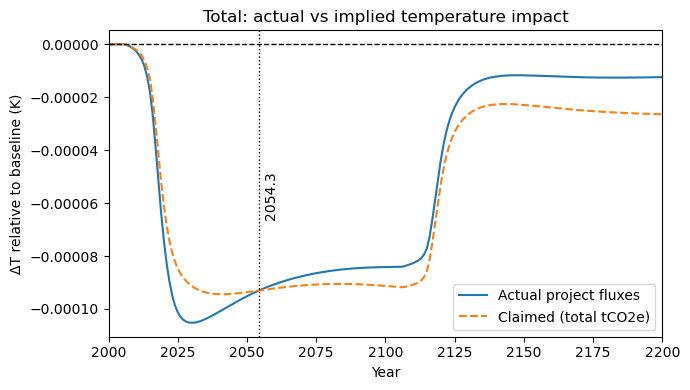

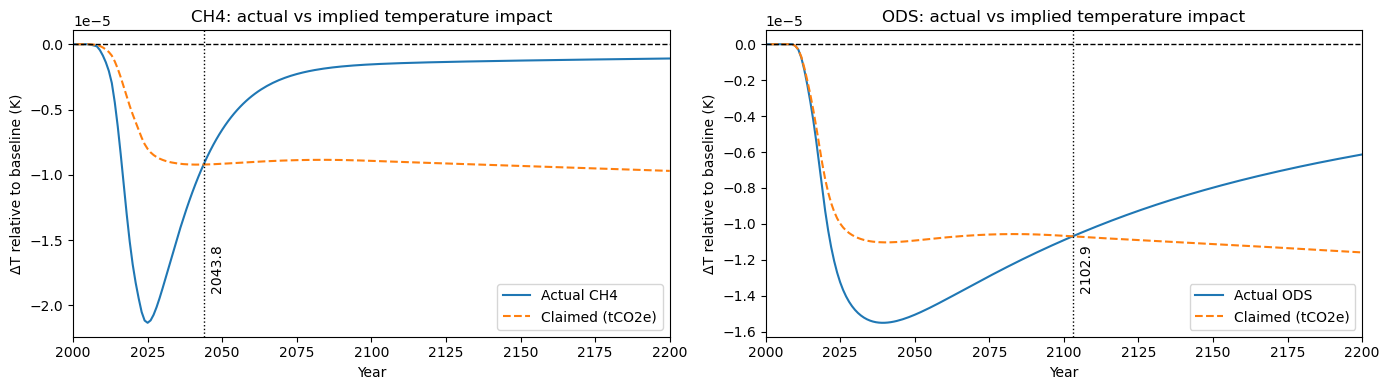

In [40]:
# calculate crossover years

#  ---  First, calculate total total  ---  
actual_diff = projects_only - baseline
claimed_diff = claimed - baseline
comparison_diff = actual_diff - claimed_diff

crossing_indices = np.where(np.diff(np.sign(comparison_diff)) != 0)[0]
crossing_indices = crossing_indices[years[crossing_indices] > 2010]

if len(crossing_indices) > 0:
    i = crossing_indices[0]
    crossover_year = years[i] - comparison_diff[i] * (years[i + 1] - years[i]) / (comparison_diff[i + 1] - comparison_diff[i])
else:
    crossover_year = np.nan

plt.figure(figsize=(7, 4))
plt.plot(years, actual_diff, label="Actual project fluxes")
plt.plot(years, claimed_diff, "--", label="Claimed (total tCO2e)")
plt.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(crossover_year):
    plt.axvline(crossover_year, linestyle=":", linewidth=1, color="k")
    plt.text(crossover_year + 2, plt.ylim()[0] * 0.6, f"{crossover_year:.1f}", rotation=90, va="bottom")

plt.xlim(2000, 2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Total: actual vs implied temperature impact")
plt.legend()
plt.tight_layout()
plt.show()

#  ---  Next, ODS and CH4-specific  ---  
ods_diff = (actual_ods_t - baseline) - (claimed_ods_t - baseline)
ods_crossing_indices = np.where(np.diff(np.sign(ods_diff)) != 0)[0]
ods_crossing_indices = ods_crossing_indices[years[ods_crossing_indices] > 2010]

if len(ods_crossing_indices) > 0:
    i = ods_crossing_indices[0]
    ods_crossover_year = years[i] - ods_diff[i] * (years[i + 1] - years[i]) / (ods_diff[i + 1] - ods_diff[i])
else:
    ods_crossover_year = np.nan

ch4_diff = (actual_ch4_t - baseline) - (claimed_ch4_t - baseline)
ch4_crossing_indices = np.where(np.diff(np.sign(ch4_diff)) != 0)[0]
ch4_crossing_indices = ch4_crossing_indices[years[ch4_crossing_indices] > 2010]

if len(ch4_crossing_indices) > 0:
    i = ch4_crossing_indices[0]
    ch4_crossover_year = years[i] - ch4_diff[i] * (years[i + 1] - years[i]) / (ch4_diff[i + 1] - ch4_diff[i])
else:
    ch4_crossover_year = np.nan

#   ---  plot temperature trajectories  ---  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ch4 temperature
ax1.plot(years, actual_ch4_t - baseline, label="Actual CH4")
ax1.plot(years, claimed_ch4_t - baseline, "--", label="Claimed (tCO2e)")
ax1.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(ch4_crossover_year):
    ax1.axvline(ch4_crossover_year, linestyle=":", linewidth=1, color="k")
    ax1.text(ch4_crossover_year + 2, ax1.get_ylim()[0] * 0.85, f"{ch4_crossover_year:.1f}", rotation=90, va="bottom")

ax1.set_xlim(2000, 2200)
ax1.set_xlabel("Year")
ax1.set_ylabel("ΔT relative to baseline (K)")
ax1.set_title("CH4: actual vs implied temperature impact")
ax1.legend()

# ods temperature
ax2.plot(years, actual_ods_t - baseline, label="Actual ODS")
ax2.plot(years, claimed_ods_t - baseline, "--", label="Claimed (tCO2e)")
ax2.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(ods_crossover_year):
    ax2.axvline(ods_crossover_year, linestyle=":", linewidth=1, color="k")
    ax2.text(ods_crossover_year + 2, ax2.get_ylim()[0] * 0.85, f"{ods_crossover_year:.1f}", rotation=90, va="bottom")

ax2.set_xlim(2000, 2200)
ax2.set_xlabel("Year")
ax2.set_ylabel("ΔT relative to baseline (K)")
ax2.set_title("ODS: actual vs implied temperature impact")
ax2.legend()

plt.tight_layout()
plt.show()

Why the crossover year is different here than above: The claimed total CO2e trajectory treats all project credits as avoided CO2, but net program uses the actual justified emissions mix, which includes CO2, CH4 and N2O.

## 2. Impact of the equivalency metric choice

Here, we test how different equivalency metrics for coverting non-CO2 gases to CO2e flux and thus justified emissions impacts the temperature trajectory and crossover year of the program as a whole. In these experiments, we remove the temporary storage component of project fluxes so crossover year is not impacted by the release of the temporary CO2 credits. We assume that the added or removed credits from equivalency metric changes are proportionally distributed amongst justified CO2 fluxes. 

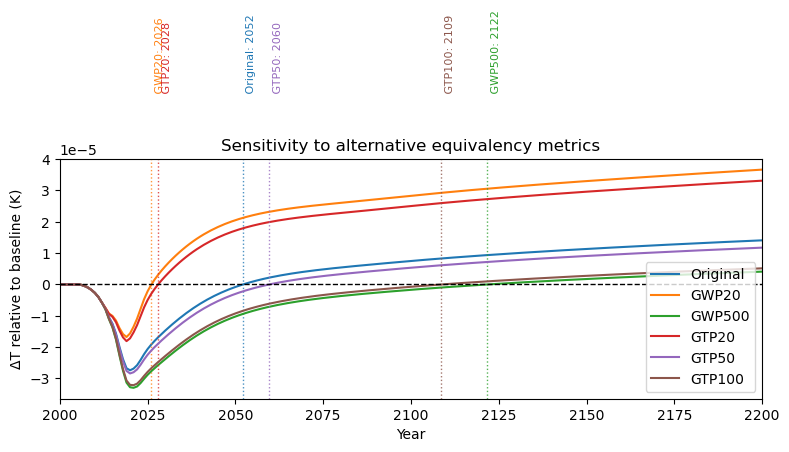

In [41]:
# Assume that all change in credits generated by using different equivalncey metrics is countered by a change in justified CO2 emissions
# Justified CH4 and N2O emissions RTS between scenarios because they make up <1% of total justified CO2e.

equiv_metrics = {
    "GWP20": {"ch4": 84, "ods": ODS_GWP20},
    "GWP500": {"ch4": 8, "ods": ODS_GWP500},
    "GTP20": {"ch4": 67, "ods": ODS_GTP20},
    "GTP50": {"ch4": 14, "ods": ODS_GTP50},
    "GTP100": {"ch4": 4, "ods": ODS_GTP100}}

def calculate_nonco2_co2e(df_p, ch4_values, ods_values):
    nonco2_co2e = df_p["ch4_flux"] * ch4_values
    for column, sp in ODS_COLUMN_TO_SPECIES.items():
        nonco2_co2e = nonco2_co2e + df_p[column] * ods_values[sp]
    return nonco2_co2e

def make_alt_justified_emissions(df_p, df_e, metric_values):
    df_alt = df_e.copy()

    # calculate original co2e using current program gwp100 assumptions
    project_co2e = df_p[["year", "ch4_flux", *ODS_COLUMNS]].copy()
    project_co2e["original_nonco2_co2e"] = calculate_nonco2_co2e(project_co2e, project_co2e["year"].apply(gwp_ch4), ODS_GWP100)

    # calculate alternative co2e using selected metric
    project_co2e["alt_nonco2_co2e"] = calculate_nonco2_co2e(project_co2e, metric_values["ch4"], metric_values["ods"])

    # difference in credited co2e relative to current accounting
    project_co2e["delta_co2e"] = project_co2e["alt_nonco2_co2e"] - project_co2e["original_nonco2_co2e"]
    delta_by_year = project_co2e.groupby("year")["delta_co2e"].sum().reset_index()

    # subtract the crediting difference from co2 justified emissions
    df_alt = df_alt.merge(delta_by_year, on="year", how="left")
    df_alt["delta_co2e"] = df_alt["delta_co2e"].fillna(0)
    df_alt["co2_justified"] = df_alt["co2_justified"] - df_alt["delta_co2e"]
    return df_alt.drop(columns="delta_co2e")

def run_program_fair(df_p, df_e_run):
    f_run = FAIR()
    f_run.define_time(1750, 2200, 1)
    f_run.define_scenarios([BASELINE_SCENARIO, "net_program"])
    f_run.define_configs(["central"])
    all_species, all_props = read_properties()

    species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES, "CO2"]
    properties = {s: all_props[s] for s in species}

    properties["CO2 FFI"]["input_mode"] = "emissions"
    properties["CO2 FFI"]["greenhouse_gas"] = False
    properties["CO2 AFOLU"]["input_mode"] = "emissions"
    properties["CO2 AFOLU"]["greenhouse_gas"] = False
    properties["CH4"]["input_mode"] = "emissions"
    properties["CH4"]["greenhouse_gas"] = True
    properties["N2O"]["input_mode"] = "emissions"
    properties["N2O"]["greenhouse_gas"] = True
    for sp in ODS_SPECIES:
        properties[sp]["input_mode"] = "emissions"
        properties[sp]["greenhouse_gas"] = True
    properties["CO2"]["input_mode"] = "calculated"
    properties["CO2"]["greenhouse_gas"] = True

    f_run.define_species(species, properties)
    f_run.allocate()
    f_run.fill_species_configs()
    fill(f_run.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
    fill(f_run.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
    fill(f_run.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

    backup = list(f_run.scenarios)
    f_run.scenarios = [BASELINE_SCENARIO]
    f_run.fill_from_rcmip()
    f_run.scenarios = backup
    for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES]:
        base = f_run.emissions.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values
        fill(f_run.emissions, base, scenario="net_program", config="central", specie=sp)
    timepoints = np.asarray(f_run.timepoints, dtype=float)

    # project fluxes
    for _, row in df_p.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CO2 FFI")].values += row["co2_flux"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CH4")].values += row["ch4_flux"] / 1e6
        for column, sp in ODS_COLUMN_TO_SPECIES.items():
            f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie=sp)].values += row[column] / 1e3

    # justified emissions
    for _, row in df_e_run.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CO2 FFI")].values += row["co2_justified"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CH4")].values += row["ch4_justified"] / 1e6
        if "n2o_justified" in df_e_run.columns:
            f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="N2O")].values += row["n2o_justified"] / 1e6

    initialise(f_run.concentration, 278.0, specie="CO2")
    initialise(f_run.concentration, 730.0, specie="CH4")
    initialise(f_run.concentration, 270.0, specie="N2O")
    for sp in ODS_SPECIES:
        initialise(f_run.concentration, 0.0, specie=sp)
    initialise(f_run.forcing, 0.0)
    initialise(f_run.temperature, 0.0)
    initialise(f_run.cumulative_emissions, 0.0)
    initialise(f_run.airborne_emissions, 0.0)
    initialise(f_run.ocean_heat_content_change, 0.0)
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            f_run.run()

    years_run = np.asarray(f_run.timebounds, dtype=float)
    baseline_temp = f_run.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)].values
    net_temp = f_run.temperature.loc[dict(scenario="net_program", config="central", layer=0)].values
    return years_run, net_temp - baseline_temp

# exclude future temporary CO2 storage re-release
df_p_metric = df_p[df_p["year"] <= 2030].copy()

# run original and alternative metric cases
temp_results = {}
years_sens, temp_results["Original"] = run_program_fair(df_p_metric, df_e)
for metric_name, metric_values in equiv_metrics.items():
    df_e_alt = make_alt_justified_emissions(
        df_p_metric, df_e, metric_values)
    _, temp_results[metric_name] = run_program_fair(
        df_p_metric, df_e_alt)

#  ---  helper: find crossover year  --- 
def find_crossover_year(years, temp):
    years = np.asarray(years)
    temp = np.asarray(temp)

    # find first transition from negative to non-negative
    idx = np.where((temp[:-1] < 0) & (temp[1:] >= 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    
    # linearly interpolate between the two surrounding points
    x0, x1 = years[i], years[i + 1]
    y0, y1 = temp[i], temp[i + 1]
    return x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

#  ---  plot temperature trajectories with crossover years  --- 
plt.figure(figsize=(8, 5))
ax = plt.gca()

for label, temp in temp_results.items():
    line, = ax.plot(years_sens, temp, label=label)
    color = line.get_color()
    crossover_year = find_crossover_year(years_sens, temp)
    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)
        ax.text(crossover_year+1, 0.00006, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=8)

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to alternative equivalency metrics")
ax.legend()
plt.tight_layout()
plt.show()

,Metric,Crossover year,CH4 credits (MtCO2e),CH4 credits (% of original),ODS credits (MtCO2e),ODS credits (% of original)
0,Original GWP100,2052.1,16.06,100.0,19.17,100.0
1,GWP20,2026.1,62.28,387.7,15.96,83.2
2,GWP500,2121.7,5.93,36.9,9.57,49.9
3,GTP20,2028.0,49.67,309.3,22.32,116.4
4,GTP50,2059.6,10.38,64.6,20.56,107.2
5,GTP100,2108.6,2.97,18.5,14.94,77.9


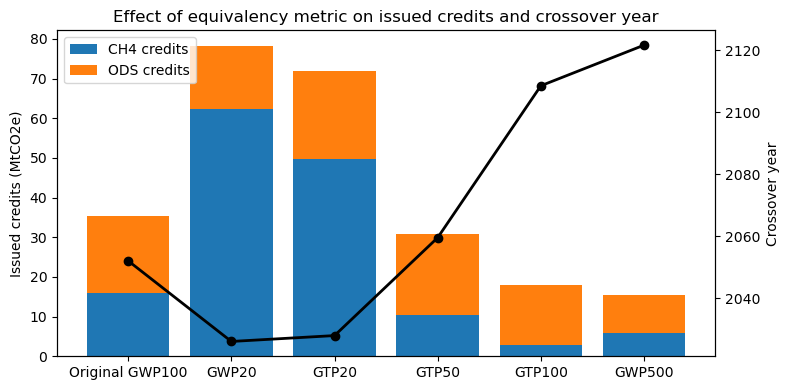

In [42]:
# ---- summarize equivalency metric results ----

equiv_summary = []

# exclude future temporary CO2 storage re-release
df_p_observed = df_p[df_p["year"] <= 2030].copy()

# original gwp100 credit totals
original_ch4_credits = -1 * (df_p_crediting["ch4_flux"] * df_p_crediting["year"].apply(gwp_ch4)).sum()
original_ods_credits = -1 * sum((df_p_crediting[column] * ODS_GWP100[sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())

equiv_summary.append({
    "metric": "Original GWP100",
    "ch4_metric": "current GWP100",
    "ods_metric": "gas-specific GWP100",
    "crossover_year": find_crossover_year(years_sens, temp_results["Original"]),
    "ch4_credits": original_ch4_credits,
    "ods_credits": original_ods_credits})

# alternative metric accounting
for metric_name, metric_values in equiv_metrics.items():
    ch4_credits = -1 * (df_p_crediting["ch4_flux"] * metric_values["ch4"]).sum()
    ods_credits = -1 * sum((df_p_crediting[column] * metric_values["ods"][sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())

    equiv_summary.append({
        "metric": metric_name,
        "ch4_metric": metric_values["ch4"],
        "ods_metric": "gas-specific",
        "crossover_year": find_crossover_year(years_sens, temp_results[metric_name]),
        "ch4_credits": ch4_credits,
        "ods_credits": ods_credits})

equiv_summary = pd.DataFrame(equiv_summary)
equiv_summary["crossover_year"] = equiv_summary["crossover_year"].round(1)
equiv_summary["ch4_credits_million"] = equiv_summary["ch4_credits"] / 1e6
equiv_summary["ods_credits_million"] = equiv_summary["ods_credits"] / 1e6
equiv_summary["ch4_credits_pct_original"] = 100 * equiv_summary["ch4_credits"] / original_ch4_credits
equiv_summary["ods_credits_pct_original"] = 100 * equiv_summary["ods_credits"] / original_ods_credits

display(equiv_summary[["metric", "crossover_year", "ch4_credits_million", "ch4_credits_pct_original", "ods_credits_million", "ods_credits_pct_original"]].rename(columns={
    "metric": "Metric",
    "crossover_year": "Crossover year",
    "ch4_credits_million": "CH4 credits (MtCO2e)",
    "ch4_credits_pct_original": "CH4 credits (% of original)",
    "ods_credits_million": "ODS credits (MtCO2e)",
    "ods_credits_pct_original": "ODS credits (% of original)"}).round({
        "Crossover year": 1,
        "CH4 credits (MtCO2e)": 2,
        "CH4 credits (% of original)": 1,
        "ODS credits (MtCO2e)": 2,
        "ODS credits (% of original)": 1}))

# ---- credits vs crossover year ----

plot_order = ["Original GWP100", "GWP20", "GTP20", "GTP50", "GTP100", "GWP500"]
plot_df = equiv_summary.set_index("metric").loc[plot_order].reset_index()

fig, ax1 = plt.subplots(figsize=(8, 4))
x = np.arange(len(plot_df))

# left axis: issued credits
ax1.bar(x, plot_df["ch4_credits_million"], label="CH4 credits")
ax1.bar(x, plot_df["ods_credits_million"], bottom=plot_df["ch4_credits_million"], label="ODS credits")
ax1.set_ylabel("Issued credits (MtCO2e)")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["metric"])
ax1.legend(loc="upper left")

# right axis: crossover year
ax2 = ax1.twinx()
ax2.plot(x, plot_df["crossover_year"], marker="o", linewidth=2, label="Crossover year", color="k")
ax2.set_ylabel("Crossover year")
ax1.set_title("Effect of equivalency metric on issued credits and crossover year")
plt.tight_layout()
plt.show()

## 3. Effect of Program Continuation

In this test, the program average CH4, ODS and Co2 project fluxes and corresponging jsutified CO2 emissions are calculated using 
CH4 and gas-specific ODS GWP100 values, then assume those project and justified fluxes continue for 200 years.

Assumptions: 
The release of temporary CO2 storage is ignored to assess SLCP temperature evolution. 
All future generated CH4 and ODS are used to justify CO2 emissions because jsutified N2O and CH4 justified emissions are small.

2010-2024 average CO2 project flux (tCO2/yr): -6142010.142857143
2010-2024 average CH4 project flux (tCH4/yr): -35304.426122448975
2010-2024 average CFC-11 project flux (tCFC-11/yr): -31.59095801550332
2010-2024 average CFC-12 project flux (tCFC-12/yr): -68.15750127961863
2010-2024 average CFC-113 project flux (tCFC-113/yr): -6.9193383925010705
2010-2024 average CFC-114 project flux (tCFC-114/yr): -3.1357486145166993
2010-2024 average CFC-115 project flux (tCFC-115/yr): -0.41747178003564106
2010-2024 average total CO2e credits (tCO2e/yr): 7937449.811918651


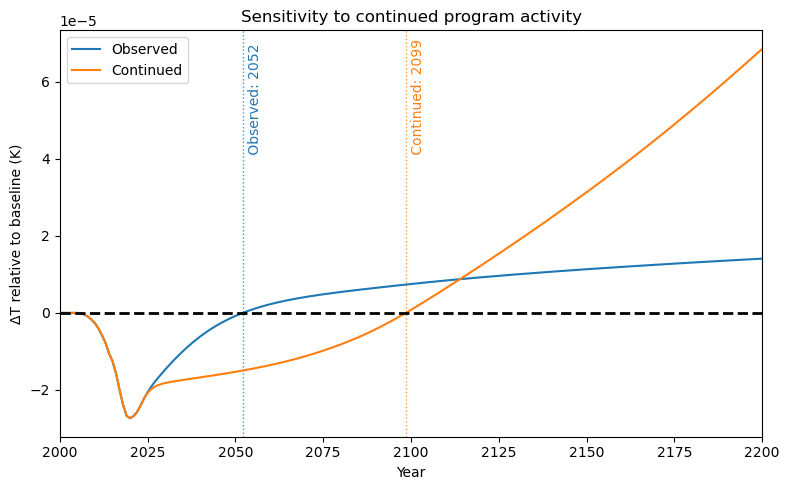

In [43]:
extension_start = 2025
extension_end = 2200

avg_window_start = 2005
avg_window_end = 2025

# ignore forest re-release rows after 2025
df_p_observed = df_p[df_p["year"] <= 2025].copy()

# calculate average annual project fluxes from 2010-2024
avg_project_fluxes = df_p_observed[(df_p_observed["year"] >= avg_window_start) & (df_p_observed["year"] <= avg_window_end)][["co2_flux", "ch4_flux", *ODS_COLUMNS]].mean()
avg_co2_flux = avg_project_fluxes["co2_flux"]
avg_ch4_flux = avg_project_fluxes["ch4_flux"]
avg_ods_fluxes = {column: avg_project_fluxes[column] for column in ODS_COLUMNS}

# convert average annual project fluxes to total co2e credits
avg_co2e_credits = -1 * (avg_co2_flux + avg_ch4_flux * 25 + sum(avg_ods_fluxes[column] * ODS_GWP100[sp] for column, sp in ODS_COLUMN_TO_SPECIES.items()))
print("2010-2024 average CO2 project flux (tCO2/yr):", avg_co2_flux)
print("2010-2024 average CH4 project flux (tCH4/yr):", avg_ch4_flux)
for column, sp in ODS_COLUMN_TO_SPECIES.items():
    print(f"2010-2024 average {sp} project flux (t{sp}/yr):", avg_ods_fluxes[column])
print("2010-2024 average total CO2e credits (tCO2e/yr):", avg_co2e_credits)

# create extension rows
extension_years = np.arange(extension_start, extension_end + 1)
df_p_extension = pd.DataFrame({"year": extension_years, "co2_flux": avg_co2_flux, "ch4_flux": avg_ch4_flux, **{column: avg_ods_fluxes[column] for column in ODS_COLUMNS}})
df_e_extension = pd.DataFrame({"year": extension_years, "co2_justified": avg_co2e_credits, "ch4_justified": 0, "n2o_justified": 0})

# combine observed and extended timeseries
df_p_continued = pd.concat([df_p_observed[df_p_observed["year"] < extension_start], df_p_extension], ignore_index=True).sort_values("year").fillna(0)
df_e_continued = pd.concat([df_e[df_e["year"] < extension_start], df_e_extension], ignore_index=True).sort_values("year")

# run observed and continued-program cases
years_observed, temp_observed = run_program_fair(df_p_observed, df_e)
years_continued, temp_continued = run_program_fair(df_p_continued, df_e_continued)

#  --- plot with crossover years  --- 
continued_results = {
    "Observed": temp_observed,
    "Continued": temp_continued}
plt.figure(figsize=(8, 5))
ax = plt.gca()
for label, temp in continued_results.items():
    line, = ax.plot(years_observed, temp, label=label)
    color = line.get_color()
    crossover_year = find_crossover_year(years_observed, temp)
    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)
        ax.text(crossover_year+1.5, 0.00004, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=10)

ax.axhline(0, linestyle="--", linewidth=2, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to continued program activity")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Effect of Non-Additionality

Here, we test how the crossover point is impacted by some proportion of either CO2, CH4, or ODS project fluxes characterized as non-additional. For example, for non-additional CH4 credits, project CH4 fluxes are lowered but justified emissions of all gases remains the same.

Gas: 100%|████████████████████████████████████████| 3/3 [00:27<00:00,  9.15s/it]

Total CO2 credits: 128982213.0
Total CH4 credits: 16061514.0
Total ODS credits: 19169409.336005956


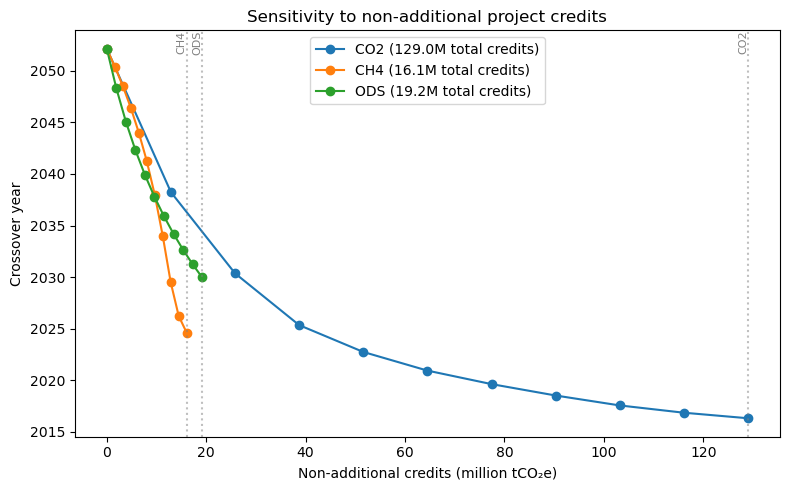

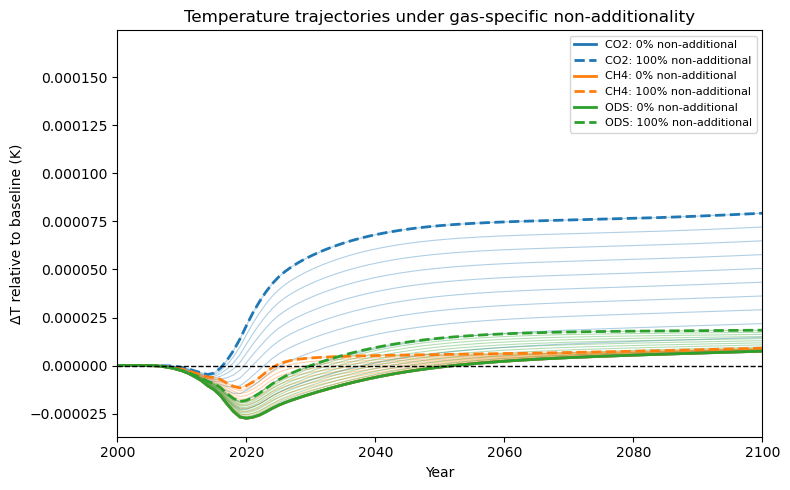

In [44]:
from tqdm import tqdm

# use crediting period only to calculate issued credits
df_p_crediting = df_p[df_p["year"] <= 2025].copy()
credit_totals = {
    "CO2": -1 * df_p_crediting["co2_flux"].sum(),
    "CH4": -1 * (df_p_crediting["ch4_flux"] * df_p_crediting["year"].apply(gwp_ch4)).sum(),
    "ODS": -1 * sum((df_p_crediting[column] * ODS_GWP100[sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())}
nonadd_results = []
nonadd_trajectories = []

for gas, total_credits in tqdm(credit_totals.items(), desc="Gas"):
    credit_steps = np.linspace(0, total_credits, 11)
    for nonadd_credits in credit_steps:
        frac_nonadd = nonadd_credits / total_credits

        # use full project time series so 2110 re-emission is retained
        df_p_test = df_p.copy()

        # only reduce project benefits during the crediting period
        crediting_mask = df_p_test["year"] <= 2025
        if gas == "CO2":
            df_p_test.loc[crediting_mask, "co2_flux"] = df_p_test.loc[crediting_mask, "co2_flux"] * (1 - frac_nonadd)
        elif gas == "CH4":
            df_p_test.loc[crediting_mask, "ch4_flux"] = df_p_test.loc[crediting_mask, "ch4_flux"] * (1 - frac_nonadd)
        elif gas == "ODS":
            for column in ODS_COLUMNS:
                df_p_test.loc[crediting_mask, column] = df_p_test.loc[crediting_mask, column] * (1 - frac_nonadd)
        years_test, temp_test = run_program_fair(df_p_test, df_e)
        crossover_year = find_crossover_year(years_test, temp_test)
        nonadd_trajectories.append({"gas": gas, "nonadd_credits": nonadd_credits, "frac_nonadd": frac_nonadd, "years": years_test, "temp": temp_test})
        nonadd_results.append({"gas": gas, "nonadd_credits": nonadd_credits, "frac_nonadd": frac_nonadd, "crossover_year": crossover_year})
nonadd_results = pd.DataFrame(nonadd_results)
print("Total CO2 credits:", credit_totals["CO2"])
print("Total CH4 credits:", credit_totals["CH4"])
print("Total ODS credits:", credit_totals["ODS"])

#  --- plot crossover year vs absolute non-additional credits  --- 
plt.figure(figsize=(8, 5))
ax = plt.gca()
for gas in ["CO2", "CH4", "ODS"]:
    plot_df = nonadd_results[nonadd_results["gas"] == gas]
    ax.plot(plot_df["nonadd_credits"] / 1e6, plot_df["crossover_year"], marker="o", label=f"{gas} ({credit_totals[gas] / 1e6:.1f}M total credits)")
for gas in ["CO2", "CH4", "ODS"]:
    ax.axvline(credit_totals[gas] / 1e6, linestyle=":", alpha=0.5, color="gray")
    ax.text(credit_totals[gas] / 1e6, ax.get_ylim()[1], gas, rotation=90, va="top", ha="right", fontsize=8, color="gray")
ax.set_xlabel("Non-additional credits (million tCO₂e)")
ax.set_ylabel("Crossover year")
ax.set_title("Sensitivity to non-additional project credits")
ax.legend()
plt.tight_layout()
plt.show()

#  ---  plot temperature trajectories for all non-additionality scenarios  --- 
colors = {
    "CO2": "tab:blue",
    "CH4": "tab:orange",
    "ODS": "tab:green"}
plt.figure(figsize=(8, 5))
ax = plt.gca()
for result in nonadd_trajectories:
    ax.plot(result["years"], result["temp"], color=colors[result["gas"]], linewidth=0.8, alpha=0.35)
for gas in ["CO2", "CH4", "ODS"]:
    gas_results = [r for r in nonadd_trajectories if r["gas"] == gas]
    zero_nonadd = min(gas_results, key=lambda x: x["frac_nonadd"])
    full_nonadd = max(gas_results, key=lambda x: x["frac_nonadd"])
    ax.plot(zero_nonadd["years"], zero_nonadd["temp"], color=colors[gas], linewidth=2, label=f"{gas}: 0% non-additional")
    ax.plot(full_nonadd["years"], full_nonadd["temp"], color=colors[gas], linewidth=2, linestyle="--", label=f"{gas}: 100% non-additional")

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2100)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Temperature trajectories under gas-specific non-additionality")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

When crossover timing is plotted against absolute CO2e credits (figure 2), CH4 and ODS non-additionality appear more sensitive per credit (steeper slope).

It is important to note that these crossover sensitivities are partly shaped by the temperature trajectory of the full program, because each gas-specific perturbation is evaluated against the same combined project and justified-emissions baseline. Sensitivities likely differ in different contexts. 